# setup


In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

np.set_printoptions(precision=3, suppress=True)

def show(images, titles, figsize=(12, 4.5)):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, img, t in zip(axes, images, titles):
        cmap = 'gray' if (img.ndim == 2) else None
        ax.imshow(img, cmap=cmap)
        ax.set_title(t)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

def to_rgb(canvas_size=(300, 300), bg=(255, 255, 255)):
    img = Image.new('RGB', canvas_size, bg)
    return img


## Task 1


Task 1: The Tiny Fingerprint - Linear Scale

Original size: 80 x 80 pixels - way too small!
Goal: scale up 300% on both axes and center it on screen.

2x2 Scaling Matrix:
[[3. 0.]
 [0. 3.]]

Each x-coordinate will be multiplied by 3.0
Each y-coordinate will be multiplied by 3.0

Scaled image size: 240 x 240
Screen size:        800 x 600
Centering offset:   tx = 280.0, ty = 180.0

2x3 Affine Matrix (scale + centering translation):
[[  3.   0. 280.]
 [  0.   3. 180.]]


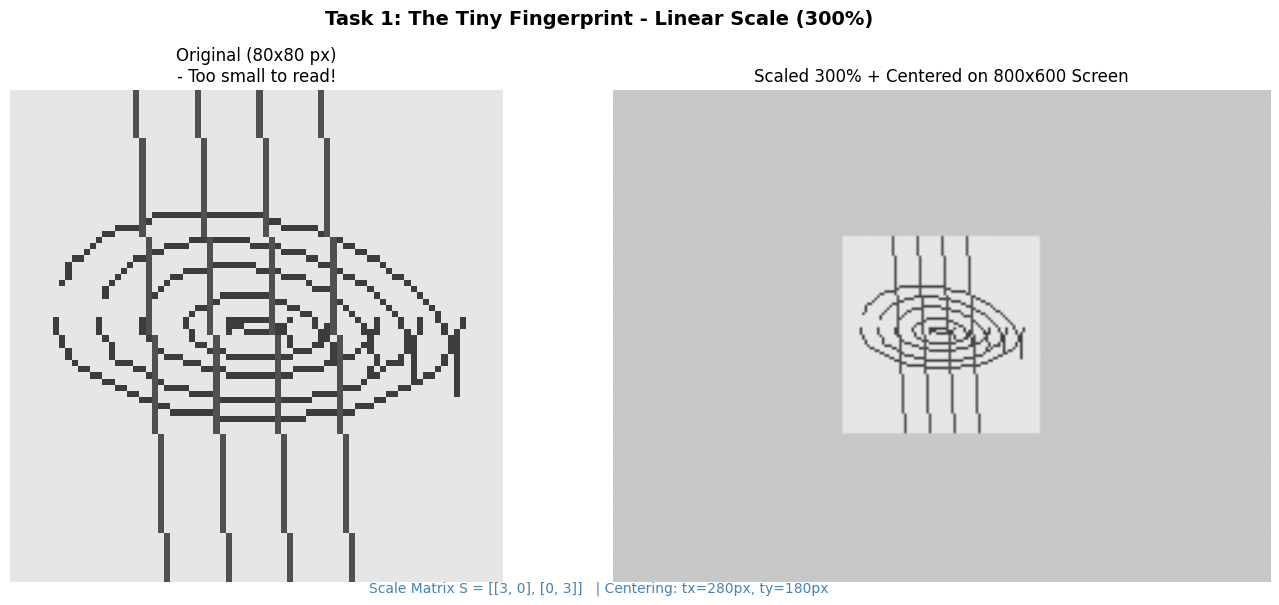

In [8]:
"""
Task 1: The Tiny Fingerprint (Linear - Scale)

Scenario:
    You're a detective analyzing a digital fingerprint from a crime scene,
    but the image is way too small to read. We need to enlarge it.

Task:
    - Manually build a 2x2 scaling matrix
    - Enlarge the fingerprint by 300% on both x and y axes
    - Calculate the translation needed to keep it perfectly centered on screen
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('output', exist_ok=True)


def make_fingerprint_image(size=80):
    """
    Creates a small synthetic fingerprint-like image using concentric arcs.
    In a real scenario you'd load an actual fingerprint image here.
    """
    img = np.ones((size, size), dtype=np.uint8) * 230  # off-white background

    cx, cy = size // 2, size // 2

    # Draw concentric elliptical arcs to simulate fingerprint ridges
    for r in range(5, size // 2 - 2, 7):
        cv2.ellipse(img, (cx, cy), (r, int(r * 0.6)), 15, 180, 360, 60, 1)
        cv2.ellipse(img, (cx, cy - 3), (r, int(r * 0.5)), 0, 0, 180, 60, 1)

    # Add a few crossing lines to make it look more like a real print
    for offset in range(-size // 4, size // 4, 10):
        cv2.line(img, (cx + offset, 0), (cx + offset + 5, size), 80, 1)

    return img


# --- Load (or create) the fingerprint image ---
fingerprint = make_fingerprint_image(size=80)
h, w = fingerprint.shape[:2]

print("=" * 50)
print("Task 1: The Tiny Fingerprint - Linear Scale")
print("=" * 50)
print(f"\nOriginal size: {w} x {h} pixels - way too small!")
print("Goal: scale up 300% on both axes and center it on screen.\n")


# --- Step 1: Build the 2x2 Scaling Matrix ---
#
# A 2D linear scale transformation is:
#
#   [ x' ]   [ sx   0 ] [ x ]
#   [ y' ] = [  0  sy ] [ y ]
#
# sx = 3.0 means 300% on x-axis (3x original size)
# sy = 3.0 means 300% on y-axis (3x original size)

sx = 3.0   # 300% horizontal scale factor
sy = 3.0   # 300% vertical scale factor

S = np.array([
    [sx,  0.0],
    [0.0,  sy]
], dtype=np.float64)

print("2x2 Scaling Matrix:")
print(S)
print(f"\nEach x-coordinate will be multiplied by {sx}")
print(f"Each y-coordinate will be multiplied by {sy}")


# --- Step 2: Calculate centering offset ---
#
# After scaling, the image dimensions become:
#   new_w = w * sx = 80 * 3 = 240
#   new_h = h * sy = 80 * 3 = 240
#
# To center this on a fixed 800x600 screen:
#   tx = (screen_w - new_w) / 2   <-- shift right to center horizontally
#   ty = (screen_h - new_h) / 2   <-- shift down to center vertically

screen_w, screen_h = 800, 600
new_w = int(w * sx)
new_h = int(h * sy)

tx = (screen_w - new_w) / 2.0
ty = (screen_h - new_h) / 2.0

print(f"\nScaled image size: {new_w} x {new_h}")
print(f"Screen size:        {screen_w} x {screen_h}")
print(f"Centering offset:   tx = {tx:.1f}, ty = {ty:.1f}")


# --- Step 3: Build the 2x3 Affine Matrix ---
#
# cv2.warpAffine() takes a 2x3 matrix that does scale AND translate in one step:
#
#   [ sx    0   tx ]
#   [  0   sy   ty ]
#
# The third column handles the centering translation.

M = np.float32([
    [sx,   0.0,  tx],
    [0.0,  sy,   ty]
])

print("\n2x3 Affine Matrix (scale + centering translation):")
print(M)


# --- Step 4: Apply the transformation ---
result = cv2.warpAffine(
    fingerprint, M,
    (screen_w, screen_h),
    flags=cv2.INTER_LINEAR,    # bilinear interpolation gives smoother edges
    borderValue=200            # fill empty screen space with light gray
)


# --- Visualize results ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Task 1: The Tiny Fingerprint - Linear Scale (300%)',
             fontsize=14, fontweight='bold')

axes[0].imshow(fingerprint, cmap='gray', vmin=0, vmax=255)
axes[0].set_title(f'Original ({w}x{h} px)\n- Too small to read!')
axes[0].axis('off')

axes[1].imshow(result, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'Scaled 300% + Centered on {screen_w}x{screen_h} Screen')
axes[1].axis('off')

matrix_text = (f"Scale Matrix S = [[{sx:.0f}, 0], [0, {sy:.0f}]]   "
               f"| Centering: tx={tx:.0f}px, ty={ty:.0f}px")
fig.text(0.5, 0.01, matrix_text, ha='center', fontsize=10, color='steelblue')

plt.tight_layout()
plt.savefig('output/task1_scale.png', dpi=100, bbox_inches='tight')
plt.show()


## Task 2

Rotation matrix R:
 [[ 0.707 -0.707]
 [ 0.707  0.707]]
Original size: 220x160  ->  New canvas size: 269x269


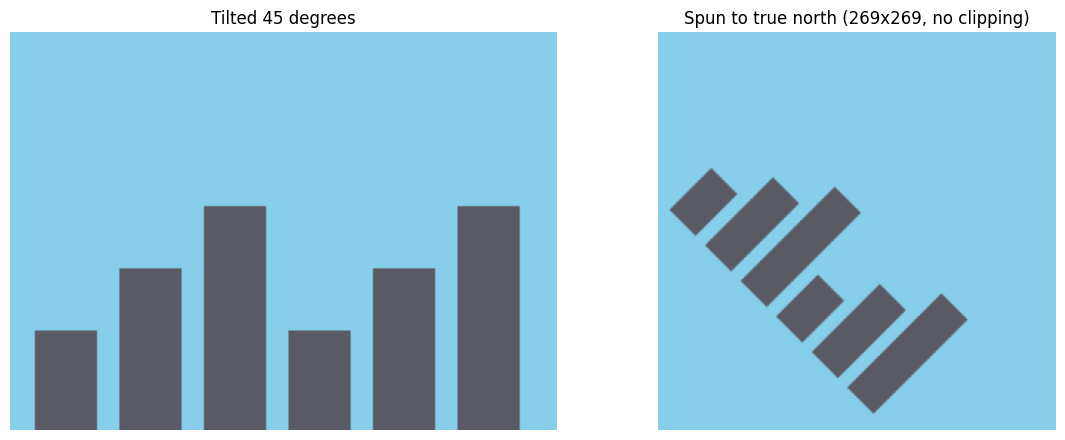

In [4]:
# --- Synthetic "city" photo: a grid of building rectangles
W, H = 220, 160
city = to_rgb((W, H), bg=(135, 206, 235))
draw = ImageDraw.Draw(city)
for i in range(6):
    x0 = 10 + i * 34
    h = 40 + (i % 3) * 25
    draw.rectangle([x0, H - h, x0 + 24, H], fill=(90, 90, 100))
city_arr = np.array(city)

theta = np.deg2rad(45)  # steep 45-degree tilt to correct

# --- Manually build the 2x2 rotation matrix with sin/cos
cos_t, sin_t = np.cos(theta), np.sin(theta)
R = np.array([[cos_t, -sin_t],
              [sin_t,  cos_t]])
print('Rotation matrix R:\n', R)

# --- Manually compute new bounding-box dimensions so corners survive the spin
new_w = int(np.ceil(abs(W * cos_t) + abs(H * sin_t)))
new_h = int(np.ceil(abs(W * sin_t) + abs(H * cos_t)))
print(f'Original size: {W}x{H}  ->  New canvas size: {new_w}x{new_h}')

# --- Rotate about the image center, then re-center into the new, larger canvas
cx, cy = W / 2, H / 2
R3 = np.array([[cos_t, -sin_t, 0], [sin_t, cos_t, 0], [0, 0, 1]])
T_to_origin = np.array([[1, 0, -cx], [0, 1, -cy], [0, 0, 1]])
T_recenter  = np.array([[1, 0, new_w / 2], [0, 1, new_h / 2], [0, 0, 1]])
M_rot = T_recenter @ R3 @ T_to_origin

rotated = cv2.warpAffine(city_arr, M_rot[:2, :], (new_w, new_h), borderValue=(135, 206, 235))
show([city_arr, rotated], ['Tilted 45 degrees', f'Spun to true north ({new_w}x{new_h}, no clipping)'])


## Task 3: The Fast Train Barcode (Linear — Shear)

Shear-correction matrix:
 [[ 1.   -0.35]
 [ 0.    1.  ]]


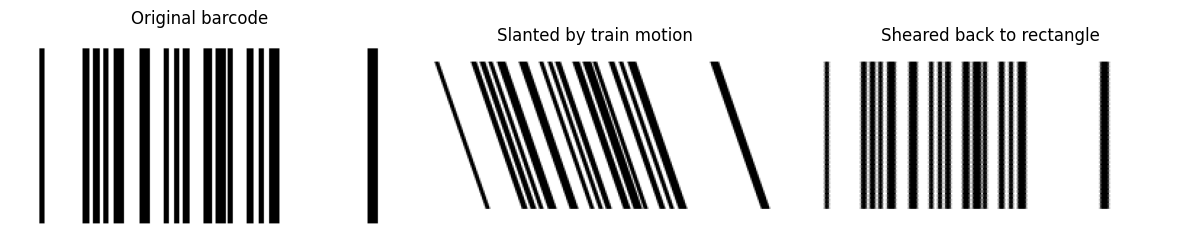

In [5]:
# --- Synthetic barcode (vertical black/white bars), then slant it to simulate the scan
W, H = 220, 120
bars = to_rgb((W, H))
draw = ImageDraw.Draw(bars)
x = 10
rng = np.random.default_rng(3)
while x < W - 10:
    w = rng.integers(2, 6)
    if rng.random() > 0.5:
        draw.rectangle([x, 10, x + w, H - 10], fill=(0, 0, 0))
    x += w + rng.integers(2, 5)
barcode = np.array(bars)

# Simulate the slant the scanner produced (shear factor k)
k_slant = 0.35
Shear_forward = np.array([[1, k_slant, 0], [0, 1, 0], [0, 0, 1]])
slanted = cv2.warpAffine(barcode, Shear_forward[:2, :], (W + int(H * k_slant), H), borderValue=(255, 255, 255))

# --- Manually build the 2x2 shear matrix that undoes the slant (push back the other way)
Sh = np.array([[1, -k_slant],
               [0, 1]])
print('Shear-correction matrix:\n', Sh)

Sh3 = np.array([[1, -k_slant, 0], [0, 1, 0], [0, 0, 1]])
out_w = slanted.shape[1]
corrected = cv2.warpAffine(slanted, Sh3[:2, :], (out_w, H), borderValue=(255, 255, 255))
show([barcode, slanted, corrected], ['Original barcode', 'Slanted by train motion', 'Sheared back to rectangle'])


## Task 4: The Hidden Treasure Map (Affine — Translation)


Translation matrix T:
 [[  1.   0. 150.]
 [  0.   1.  80.]
 [  0.   0.   1.]]


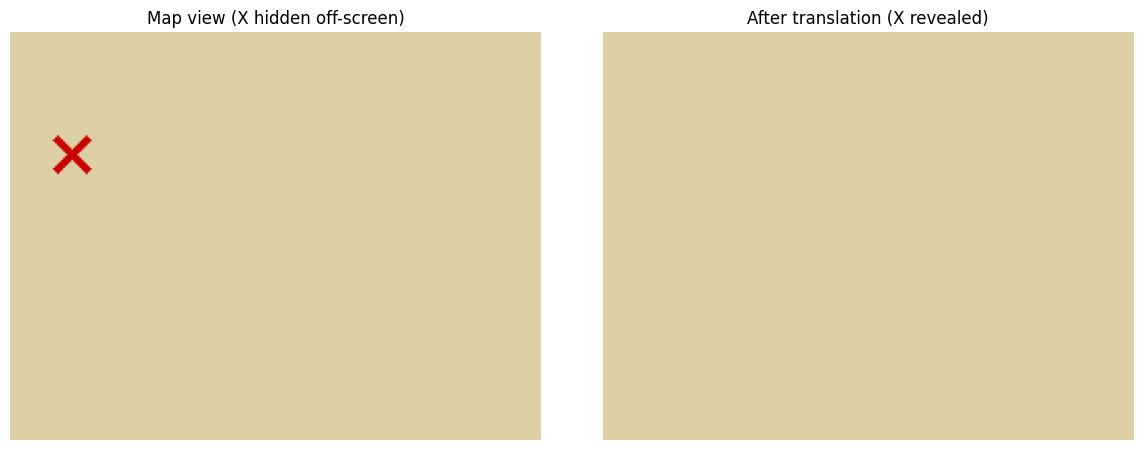

In [6]:
# --- Synthetic map with an "X" mark that is off-canvas (top-left, out of frame)
W, H = 260, 200
map_canvas = to_rgb((W, H), bg=(222, 208, 165))
draw = ImageDraw.Draw(map_canvas)
# X is drawn at a position that is 150 left / 80 up relative to where it SHOULD be
x_true, y_true = 180, 140          # where the X should end up (visible, centered-ish)
x_hidden, y_hidden = x_true - 150, y_true - 80   # off-screen (negative-ish) position
big = to_rgb((W + 200, H + 200), bg=(222, 208, 165))
bd = ImageDraw.Draw(big)
d = 8
bd.line([x_hidden + 100 - d, y_hidden + 100 - d, x_hidden + 100 + d, y_hidden + 100 + d], fill=(200, 0, 0), width=3)
bd.line([x_hidden + 100 - d, y_hidden + 100 + d, x_hidden + 100 + d, y_hidden + 100 - d], fill=(200, 0, 0), width=3)
big_arr = np.array(big)
visible_crop = big_arr[100:100 + H, 100:100 + W]  # what the user currently sees: X is missing (off-frame)

# --- Build the 3x3 translation matrix: shift +150 right, +80 down to bring X into frame
tx, ty = 150, 80
Tmat = np.array([[1, 0, tx],
                  [0, 1, ty],
                  [0, 0, 1]], dtype=np.float64)
print('Translation matrix T:\n', Tmat)

shifted = cv2.warpAffine(big_arr, Tmat[:2, :], (W, H), borderValue=(222, 208, 165))
shifted_crop = shifted[0:H, 0:W]
show([visible_crop, shifted_crop], ['Map view (X hidden off-screen)', 'After translation (X revealed)'])


## Task 5: The Robot's Assembly Line (Rigid Transformation)


Combined rigid matrix:
 [[  0.951  -0.309 130.   ]
 [  0.309   0.951 -50.   ]
 [  0.      0.      1.   ]]


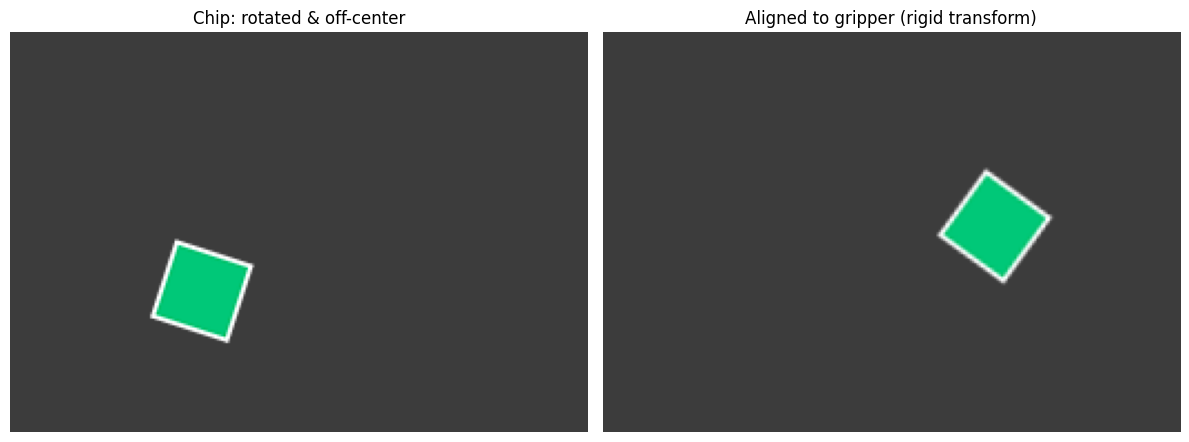

In [7]:
# --- Synthetic chip (small rotated square) sitting off-center on a belt
W, H = 260, 180
belt = to_rgb((W, H), bg=(60, 60, 60))
chip_size = 40
chip_img = Image.new('RGBA', (chip_size, chip_size), (0, 0, 0, 0))
cd = ImageDraw.Draw(chip_img)
cd.rectangle([2, 2, chip_size - 2, chip_size - 2], fill=(0, 200, 120, 255), outline=(255, 255, 255, 255), width=2)
chip_rot = chip_img.rotate(-18, expand=True, resample=Image.BICUBIC)  # chip is rotated on the belt
chip_pos = (60, 90)  # off-center position, in belt coordinates
belt.paste(chip_rot, chip_pos, chip_rot)
belt_arr = np.array(belt)

theta = np.deg2rad(18)                 # undo the 18-degree rotation
gripper_target = (190, 40)             # where the gripper needs the chip's corner

# --- Rotation matrix + Translation matrix, combined into ONE 3x3 rigid matrix
cos_t, sin_t = np.cos(theta), np.sin(theta)
R3 = np.array([[cos_t, -sin_t, 0],
               [sin_t,  cos_t, 0],
               [0,      0,     1]])
tx = gripper_target[0] - chip_pos[0]
ty = gripper_target[1] - chip_pos[1]
T3 = np.array([[1, 0, tx],
               [0, 1, ty],
               [0, 0, 1]])
M_rigid = T3 @ R3       # single combined rigid-body matrix (rotation then translation)
print('Combined rigid matrix:\n', M_rigid)

aligned = cv2.warpAffine(belt_arr, M_rigid[:2, :], (W, H), borderValue=(60, 60, 60))
show([belt_arr, aligned], ['Chip: rotated & off-center', 'Aligned to gripper (rigid transform)'])


## Task 6: The Architect's Blueprint (Similarity Transformation)


Similarity matrix (scale+rotate+translate):
 [[  2.266   1.057 -17.544]
 [ -1.057   2.266  65.705]
 [  0.      0.      1.   ]]


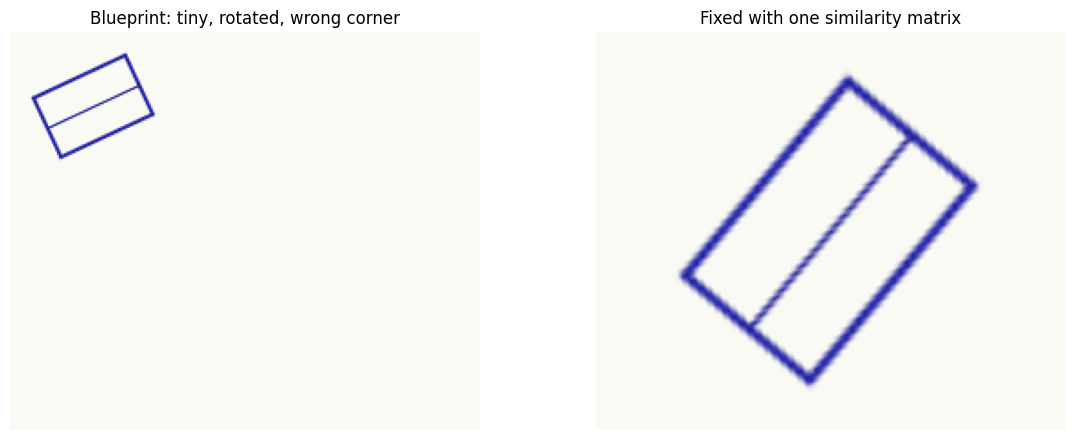

In [9]:
# --- Synthetic blueprint: a small rotated rectangle "floor plan" in the wrong corner
W, H = 260, 220
sheet = to_rgb((W, H), bg=(250, 250, 245))
plan = Image.new('RGBA', (60, 40), (0, 0, 0, 0))
pd = ImageDraw.Draw(plan)
pd.rectangle([1, 1, 58, 38], outline=(30, 30, 150, 255), width=2)
pd.line([1, 20, 58, 20], fill=(30, 30, 150, 255), width=1)
plan_rot = plan.rotate(25, expand=True, resample=Image.BICUBIC)
plan_pos = (10, 10)   # wrong corner (top-left), too small
sheet.paste(plan_rot, plan_pos, plan_rot)
sheet_arr = np.array(sheet)

scale = 2.5                 # too small -> enlarge
theta = np.deg2rad(-25)     # undo the random rotation
target_center = (W // 2, H // 2)   # move to the correct spot (center of sheet)
src_center = (plan_pos[0] + plan_rot.width / 2, plan_pos[1] + plan_rot.height / 2)

# --- Scale, Rotation, Translation combined into ONE 3x3 similarity matrix
cos_t, sin_t = np.cos(theta), np.sin(theta)
Sc = np.array([[scale, 0, 0], [0, scale, 0], [0, 0, 1]])
Rt = np.array([[cos_t, -sin_t, 0], [sin_t, cos_t, 0], [0, 0, 1]])
T_to_origin = np.array([[1, 0, -src_center[0]], [0, 1, -src_center[1]], [0, 0, 1]])
T_to_target = np.array([[1, 0, target_center[0]], [0, 1, target_center[1]], [0, 0, 1]])

M_sim = T_to_target @ Rt @ Sc @ T_to_origin
print('Similarity matrix (scale+rotate+translate):\n', M_sim)

fixed = cv2.warpAffine(sheet_arr, M_sim[:2, :], (W, H), borderValue=(250, 250, 245))
show([sheet_arr, fixed], ['Blueprint: tiny, rotated, wrong corner', 'Fixed with one similarity matrix'])


## Task 7: The Glitched Image (General Affine Transformation)


Recovered affine matrix:
 [[ 0.8   0.35 20.  ]
 [-0.25  0.9  15.  ]]
True affine matrix (for comparison):
 [[ 0.8   0.35 20.  ]
 [-0.25  0.9  15.  ]]


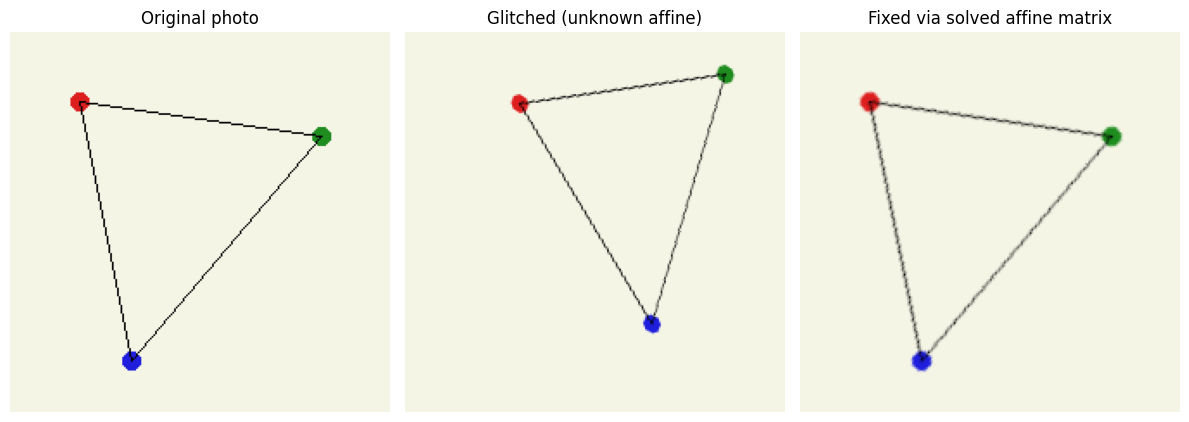

In [10]:
# --- Synthetic photo with 3 clear landmarks (colored dots), then glitch it
W, H = 220, 220
photo = to_rgb((W, H), bg=(245, 245, 230))
pd = ImageDraw.Draw(photo)
landmarks_src = np.array([[40, 40], [180, 60], [70, 190]], dtype=np.float64)  # 3 landmarks, original photo
colors = [(220, 30, 30), (30, 140, 30), (30, 30, 220)]
for (x, y), c in zip(landmarks_src, colors):
    pd.ellipse([x - 5, y - 5, x + 5, y + 5], fill=c)
pd.polygon([tuple(p) for p in landmarks_src], outline=(0, 0, 0))
photo_arr = np.array(photo)

# Corrupt it with an unknown general affine warp (squish+slant+rotate+move)
A_true = np.array([[0.8, 0.35, 20], [-0.25, 0.9, 15]])
glitched = cv2.warpAffine(photo_arr, A_true, (W, H), borderValue=(245, 245, 230))
# The landmarks' new (corrupted) positions -- these are what we CAN measure in the glitched photo
landmarks_dst = (A_true[:, :2] @ landmarks_src.T + A_true[:, 2:3]).T

# --- Solve a 6x6 linear system for the unknown affine matrix [a b c; d e f]
# Each point gives 2 equations:  x' = a*x + b*y + c   and   y' = d*x + e*y + f
rows_top, rows_bot, rhs_top, rhs_bot = [], [], [], []
for (x, y), (xp, yp) in zip(landmarks_src, landmarks_dst):
    rows_top.append([x, y, 1, 0, 0, 0]); rhs_top.append(xp)
    rows_bot.append([0, 0, 0, x, y, 1]); rhs_bot.append(yp)
Lhs = np.array(rows_top + rows_bot)
Rhs = np.array(rhs_top + rhs_bot)
unknowns = np.linalg.solve(Lhs, Rhs)   # [a, b, c, d, e, f]
a, b, c, d, e, f = unknowns
A_recovered = np.array([[a, b, c], [d, e, f]])
print('Recovered affine matrix:\n', A_recovered)
print('True affine matrix (for comparison):\n', A_true)

# Undo it: fix the image with the inverse of the recovered matrix
A_recovered_3x3 = np.vstack([A_recovered, [0, 0, 1]])
A_inv = np.linalg.inv(A_recovered_3x3)
fixed = cv2.warpAffine(glitched, A_inv[:2, :], (W, H), borderValue=(245, 245, 230))
show([photo_arr, glitched, fixed], ['Original photo', 'Glitched (unknown affine)', 'Fixed via solved affine matrix'])


## Task 8: The Sidewalk Illusion (Projective — Perspective)

Perspective matrix:
 [[   2.       0.5   -130.   ]
 [  -0.       2.4    -48.   ]
 [   0.       0.004    1.   ]]


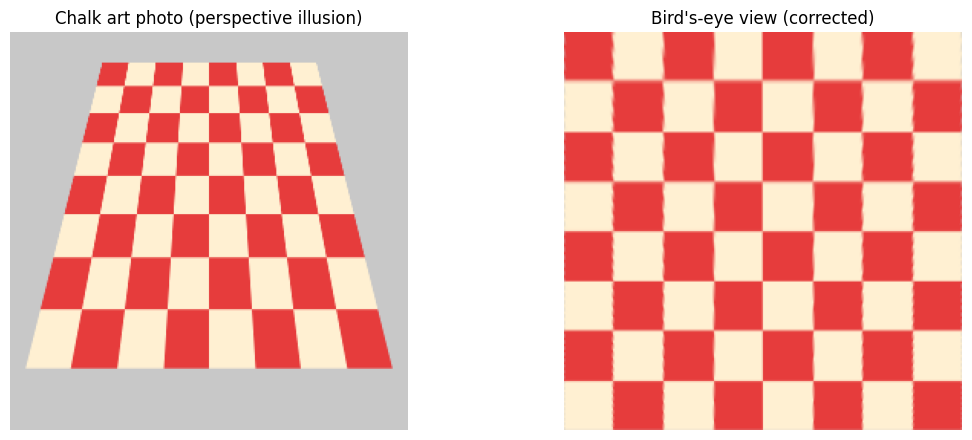

In [11]:
# --- Synthetic chalk-art photo: a checkerboard square photographed at a raking angle
size = 260
board = np.zeros((8, 8, 3), dtype=np.uint8)
board[::2, ::2] = (230, 60, 60); board[1::2, 1::2] = (230, 60, 60)
board[::2, 1::2] = (255, 240, 210); board[1::2, ::2] = (255, 240, 210)
board_img = Image.fromarray(board).resize((size, size), Image.NEAREST)

# The 4 corners of the square, AS THEY APPEAR in the photo (perspective foreshortening:
# far edge -- top -- looks narrower than the near edge -- bottom)
src_pts = np.float32([[60, 20], [200, 20], [250, 220], [10, 220]])   # TL, TR, BR, BL (distorted)
dst_pts = np.float32([[0, 0], [size, 0], [size, size], [0, size]])    # a perfect square

canvas = to_rgb((size, size), bg=(200, 200, 200))
canvas_arr = np.array(canvas)
# Paste the true square warped INTO the src quad, to fabricate the 'photo with illusion'
H_fake = cv2.getPerspectiveTransform(dst_pts, src_pts)
illusion_photo = cv2.warpPerspective(np.array(board_img), H_fake, (size, size), canvas_arr.copy(),
                                      borderMode=cv2.BORDER_TRANSPARENT)

# --- Build the perspective transformation matrix mapping the 4 photographed
# corners to a perfect square (top-down / bird's-eye view)
H_persp = cv2.getPerspectiveTransform(src_pts, dst_pts)
print('Perspective matrix:\n', H_persp)

birdseye = cv2.warpPerspective(illusion_photo, H_persp, (size, size), borderValue=(200, 200, 200))
show([illusion_photo, birdseye], ['Chalk art photo (perspective illusion)', 'Bird\'s-eye view (corrected)'])


## Task 9: The Stadium Panorama (Projective — Homography)


Homography matrix:
 [[  1.   0. 200.]
 [  0.   1.  -0.]
 [  0.   0.   1.]]


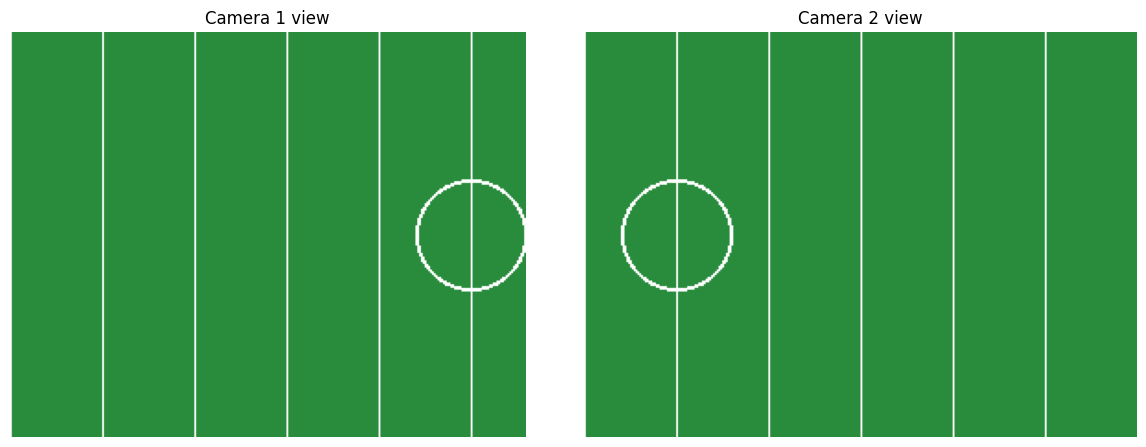

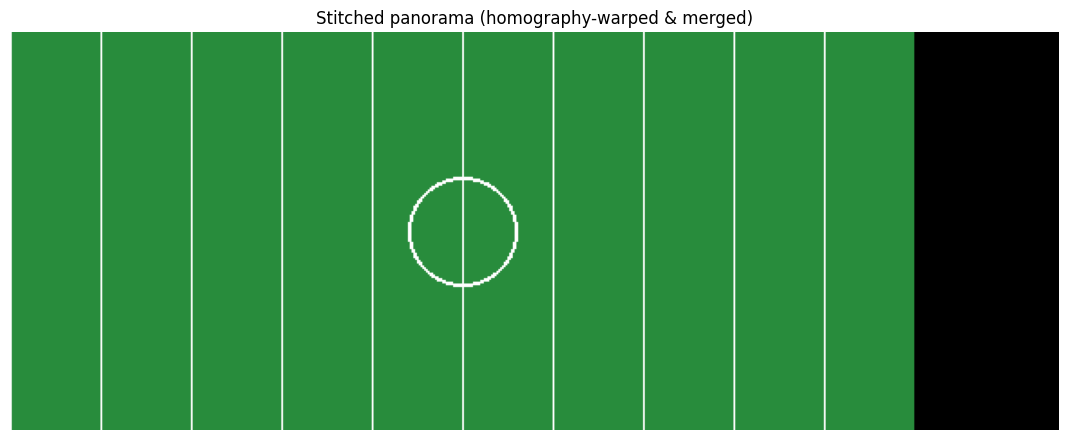

In [12]:
# --- Build two synthetic "camera views" of the same football field with an overlap region
field_w, field_h = 500, 220
field = to_rgb((field_w, field_h), bg=(40, 140, 60))
fd = ImageDraw.Draw(field)
for x in range(0, field_w, 50):
    fd.line([x, 0, x, field_h], fill=(255, 255, 255), width=1)
fd.ellipse([field_w // 2 - 30, field_h // 2 - 30, field_w // 2 + 30, field_h // 2 + 30], outline=(255, 255, 255), width=2)
field_arr = np.array(field)

cam1 = field_arr[:, 0:280]          # left camera sees columns 0-280
cam2 = field_arr[:, 200:500]        # right camera sees columns 200-500 (overlap: 200-280)

# --- 4 matching points found in BOTH images (same physical field markings),
# expressed in each camera's own local pixel coordinates
pts_cam1 = np.float32([[200, 20], [250, 20], [200, 200], [250, 200]])   # in cam1's frame
pts_cam2 = np.float32([[0, 20],   [50, 20],  [0, 200],   [50, 200]])    # SAME 4 points in cam2's frame

# --- Compute the Homography that projects cam2's view into cam1's coordinate space
Hmat, _ = cv2.findHomography(pts_cam2, pts_cam1)
print('Homography matrix:\n', Hmat)

pano_w = cam1.shape[1] + cam2.shape[1]
pano = np.zeros((field_h, pano_w, 3), dtype=np.uint8)
pano[:, :cam1.shape[1]] = cam1                                   # place cam1 as-is
warped_cam2 = cv2.warpPerspective(cam2, Hmat, (pano_w, field_h))  # project cam2 into cam1's space
mask = (warped_cam2.sum(axis=2) > 0)
pano[mask] = warped_cam2[mask]                                   # stitch together

show([cam1, cam2], ['Camera 1 view', 'Camera 2 view'])
show([pano], ['Stitched panorama (homography-warped & merged)'])


## Task 10: The Master Forger (Full Hierarchy Challenge)


After Linear Scale, corners:
 [[  0.   0.]
 [210.   0.]
 [210. 154.]
 [  0. 154.]]

After Rigid Transformation (moved near frame), corners:
 [[100.  30.]
 [310.  30.]
 [310. 184.]
 [100. 184.]]

Final projective (homography) matrix onto the frame:
 [[ 1.025 -0.114 13.904]
 [ 0.169  1.103 -8.905]
 [ 0.    -0.     1.   ]]


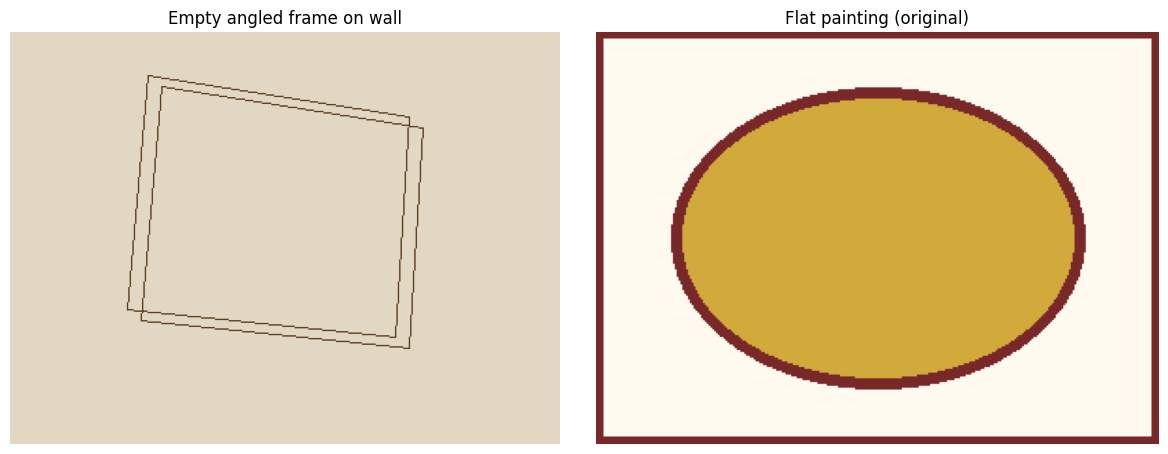

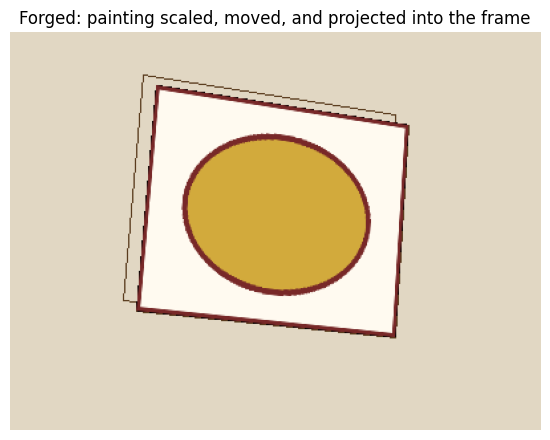

In [13]:
# --- Synthetic museum wall with an empty, angled picture frame
wall_w, wall_h = 400, 300
wall = to_rgb((wall_w, wall_h), bg=(225, 215, 195))
wd = ImageDraw.Draw(wall)
# The empty frame's 4 inner corners, drawn at an angle (perspective on the wall)
frame_corners = np.float32([[110, 40], [300, 70], [290, 230], [95, 210]])  # TL, TR, BR, BL
wd.polygon([tuple(p) for p in frame_corners], outline=(90, 60, 30))
wd.polygon([tuple(p + [-10, -8]) for p in frame_corners], outline=(90, 60, 30))  # frame border
wall_arr = np.array(wall)

# --- The flat painting (start large, un-rotated, far from the frame)
paint_w, paint_h = 300, 220
painting = to_rgb((paint_w, paint_h), bg=(255, 250, 240))
pd = ImageDraw.Draw(painting)
pd.ellipse([40, 30, 260, 190], fill=(210, 170, 60), outline=(120, 40, 40), width=6)
pd.rectangle([0, 0, paint_w - 1, paint_h - 1], outline=(120, 40, 40), width=4)
painting_arr = np.array(painting)
paint_corners_original = np.float32([[0, 0], [paint_w, 0], [paint_w, paint_h], [0, paint_h]])

# STEP 1 -- LINEAR SCALE: shrink the painting down towards the frame's rough size
scale = 0.7
S3 = np.array([[scale, 0, 0], [0, scale, 0], [0, 0, 1]])
shrunk_corners = (S3[:2, :2] @ paint_corners_original.T).T
print('After Linear Scale, corners:\n', shrunk_corners)

# STEP 2 -- RIGID TRANSFORMATION: move (translate, no rotation needed here) the
# shrunk painting near the frame's location on the wall
target_near_frame = np.float32([[100, 30], [100 + paint_w * scale, 30],
                                 [100 + paint_w * scale, 30 + paint_h * scale], [100, 30 + paint_h * scale]])
tx = target_near_frame[0, 0] - shrunk_corners[0, 0]
ty = target_near_frame[0, 1] - shrunk_corners[0, 1]
T3 = np.array([[1, 0, tx], [0, 1, ty], [0, 0, 1]])
moved_corners = (shrunk_corners + [tx, ty])
print('\nAfter Rigid Transformation (moved near frame), corners:\n', moved_corners)

# STEP 3 -- PROJECTIVE TRANSFORMATION: warp the moved painting's 4 corners
# EXACTLY onto the angled frame's 4 corners (final forgery step)
H_final = cv2.getPerspectiveTransform(moved_corners.astype(np.float32), frame_corners)
print('\nFinal projective (homography) matrix onto the frame:\n', H_final)

# Compose the FULL hierarchy as one pipeline: Scale -> Translate -> Project
# (equivalent to warping straight from the ORIGINAL painting corners with H_final @ T3 @ S3)
M_full = H_final @ T3 @ S3
warped_painting = cv2.warpPerspective(painting_arr, M_full, (wall_w, wall_h))

mask = (warped_painting.sum(axis=2) > 0)
forged = wall_arr.copy()
forged[mask] = warped_painting[mask]

show([wall_arr, painting_arr], ['Empty angled frame on wall', 'Flat painting (original)'])
show([forged], ['Forged: painting scaled, moved, and projected into the frame'])
